<a href="https://colab.research.google.com/github/pandeychetanya/HalloweenFlutter/blob/main/Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (Open Weather Map Data)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set(style='whitegrid')

## Load Data, Clean Dates, and Inspect Data

In [ ]:
data = pd.read_csv('/content/OpenWeatherMap_Data.csv')

In [ ]:
df = data.copy()

# Convert Unix timestamp to UTC datetime
df['dt'] = pd.to_datetime(df['dt'].astype(int), unit='s', utc=True)

# Use the timezone offset column (in seconds) to compute local time
df['timezone_offset'] = pd.to_timedelta(df['timezone'], unit='s')

# Apply the offset to get local time
df['dt_local'] = df['dt'] + df['timezone_offset']

# Set local time as index
df = df.set_index('dt_local').sort_index()

df.head(20)

,dt,dt_iso,timezone,city_name,lat,lon,temp,visibility,dew_point,feels_like,...,rain_1h,rain_3h,snow_1h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon,timezone_offset
dt_local,,,,,,,,,,,,,,,,,,,,,
1978-12-31 16:00:00+00:00,1979-01-01 00:00:00+00:00,1979-01-01 00:00:00 +0000 UTC,-28800,Stanford University,37.427660,-122.170060,45.14,NaN,30.97,43.29,...,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01d,-1 days +16:00:00
1978-12-31 16:00:00+00:00,1979-01-01 00:00:00+00:00,1979-01-01 00:00:00 +0000 UTC,-28800,Palo Alto,37.441883,-122.143019,45.30,NaN,31.10,43.48,...,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01d,-1 days +16:00:00
1978-12-31 16:00:00+00:00,1979-01-01 00:00:00+00:00,1979-01-01 00:00:00 +0000 UTC,-28800,Menlo Park,37.452960,-122.181725,45.14,NaN,30.97,43.29,...,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01d,-1 days +16:00:00
1978-12-31 16:00:00+00:00,1979-01-01 00:00:00+00:00,1979-01-01 00:00:00 +0000 UTC,-28800,Stanford,37.424106,-122.166076,45.12,NaN,30.96,43.27,...,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01d,-1 days +16:00:00
1978-12-31 16:00:00+00:00,1979-01-01 00:00:00+00:00,1979-01-01 00:00:00 +0000 UTC,-28800,Redwood City,37.484795,-122.228141,45.36,NaN,31.15,43.54,...,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01d,-1 days +16:00:00
1978-12-31 17:00:00+00:00,1979-01-01 01:00:00+00:00,1979-01-01 01:00:00 +0000 UTC,-28800,Palo Alto,37.441883,-122.143019,46.22,10000.0,17.55,43.41,...,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01d,-1 days +16:00:00
1978-12-31 17:00:00+00:00,1979-01-01 01:00:00+00:00,1979-01-01 01:00:00 +0000 UTC,-28800,Stanford,37.424106,-122.166076,45.39,NaN,27.46,44.04,...,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01d,-1 days +16:00:00
1978-12-31 17:00:00+00:00,1979-01-01 01:00:00+00:00,1979-01-01 01:00:00 +0000 UTC,-28800,Menlo Park,37.452960,-122.181725,45.43,NaN,27.50,44.10,...,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01d,-1 days +16:00:00
1978-12-31 17:00:00+00:00,1979-01-01 01:00:00+00:00,1979-01-01 01:00:00 +0000 UTC,-28800,Stanford University,37.427660,-122.170060,45.43,NaN,27.50,44.10,...,NaN,NaN,NaN,NaN,0,800,Clear,sky is clear,01d,-1 days +16:00:00


In [ ]:
# check counts and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2032023 entries, 1978-12-31 16:00:00+00:00 to 2024-12-15 15:00:00+00:00
Data columns (total 29 columns):
 #   Column               Dtype              
---  ------               -----              
 0   dt                   datetime64[ns, UTC]
 1   dt_iso               object             
 2   timezone             int64              
 3   city_name            object             
 4   lat                  float64            
 5   lon                  float64            
 6   temp                 float64            
 7   visibility           float64            
 8   dew_point            float64            
 9   feels_like           float64            
 10  temp_min             float64            
 11  temp_max             float64            
 12  pressure             int64              
 13  sea_level            float64            
 14  grnd_level           float64            
 15  humidity             int64              
 16  wind_spee

In [ ]:
# summary statistics
print(df.describe())

           timezone           lat           lon          temp     visibility  \
count  2.032023e+06  2.032023e+06  2.032023e+06  2.032023e+06  941389.000000   
mean  -2.668909e+04  3.744629e+01 -1.221777e+02  5.834180e+01    9640.139029   
std    1.772946e+03  2.182094e-02  2.815063e-02  9.553878e+00    1317.496364   
min   -2.880000e+04  3.742411e+01 -1.222281e+02  2.354000e+01       3.000000   
25%   -2.880000e+04  3.742766e+01 -1.221817e+02  5.162000e+01   10000.000000   
50%   -2.520000e+04  3.744188e+01 -1.221701e+02  5.738000e+01   10000.000000   
75%   -2.520000e+04  3.745296e+01 -1.221661e+02  6.415000e+01   10000.000000   
max   -2.520000e+04  3.748479e+01 -1.221430e+02  1.075800e+02   10000.000000   

          dew_point    feels_like      temp_min      temp_max      pressure  \
count  2.032023e+06  2.032023e+06  2.032023e+06  2.032023e+06  2.032023e+06   
mean   4.972891e+01  5.739355e+01  5.672769e+01  6.007715e+01  1.016412e+03   
std    7.779987e+00  1.012941e+01  9.25959

## Create Month-Aggregated Data Frame

In [ ]:
# Extract the local month for grouping
df = df.reset_index()
df['month'] = df['dt_local'].dt.to_period('M')

# Define which numeric features to average across the month
numeric_columns = [
    'temp', 'feels_like', 'temp_min', 'temp_max', 'dew_point', 'humidity',
    'pressure', 'sea_level', 'grnd_level',
    'visibility', 'wind_speed', 'wind_deg', 'wind_gust',
    'clouds_all'
]

# Custom aggregation logic per city-month
def custom_monthly_aggregator(group):
    summary = {}

    # Monthly average for core numeric features
    for col in numeric_columns:
        summary[col] = group[col].mean()

    # Only sum 1-hour rain and snow (in mm), leave NaNs alone
    summary['total_rain_mm'] = group['rain_1h'].sum()
    summary['total_snow_mm'] = group['snow_1h'].sum()

    # Count of hours with any 1-hour rain or snow recorded
    summary['rain_hours'] = (group['rain_1h'] > 0).sum()
    summary['snow_hours'] = (group['snow_1h'] > 0).sum()

    # Frequency counts for weather categories
    summary['weather_main_counts'] = group['weather_main'].value_counts().to_dict()
    summary['weather_description_counts'] = group['weather_description'].value_counts().to_dict()

    return pd.Series(summary)

# Apply aggregation per city and month
monthly_summary = df.groupby(['city_name', 'month']).apply(custom_monthly_aggregator).reset_index()



<ipython-input-89-1656462333>:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['dt_local'].dt.to_period('M')
<ipython-input-89-1656462333>:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_summary = df.groupby(['city_name', 'month']).apply(custom_monthly_aggregator).reset_index()


In [ ]:
monthly_summary[monthly_summary['city_name']=="Stanford University"].head(30)

,city_name,month,temp,feels_like,temp_min,temp_max,dew_point,humidity,pressure,sea_level,...,wind_speed,wind_deg,wind_gust,clouds_all,total_rain_mm,total_snow_mm,rain_hours,snow_hours,weather_main_counts,weather_description_counts
2212,Stanford University,1978-12,38.781250,38.225000,35.611250,43.577500,28.006250,64.750000,1024.500000,NaN,...,2.900000,232.625000,NaN,0.000000,0.00,0.0,0,0,{'Clear': 8},{'sky is clear': 8}
2213,Stanford University,1979-01,47.209019,45.350726,46.017608,48.458038,42.177446,83.576613,1016.704301,NaN,...,5.208145,165.668011,NaN,65.342742,128.55,0.0,122,0,"{'Clouds': 457, 'Clear': 165, 'Rain': 122}","{'overcast clouds': 293, 'sky is clear': 165, ..."
2214,Stanford University,1979-02,49.526146,48.002798,48.352902,50.775625,44.253095,82.822917,1019.385417,NaN,...,5.229732,208.962798,NaN,69.648810,137.62,0.0,140,0,"{'Clouds': 459, 'Rain': 140, 'Clear': 73}","{'overcast clouds': 256, 'broken clouds': 94, ..."
2215,Stanford University,1979-03,53.304530,52.212917,52.235202,54.513884,47.973132,82.813172,1016.975806,NaN,...,4.854301,227.251344,NaN,61.829301,80.85,0.0,115,0,"{'Clouds': 509, 'Clear': 120, 'Rain': 115}","{'overcast clouds': 233, 'broken clouds': 120,..."
2216,Stanford University,1979-04,54.751502,53.507997,53.581613,55.978359,48.260070,79.652295,1017.808067,NaN,...,6.482587,262.787204,NaN,50.970793,17.41,0.0,52,0,"{'Clouds': 485, 'Clear': 182, 'Rain': 52}","{'overcast clouds': 208, 'sky is clear': 182, ..."
2217,Stanford University,1979-05,60.614866,59.918871,59.044005,62.120941,52.777285,77.538978,1014.369624,NaN,...,5.647755,257.805108,NaN,37.969086,11.66,0.0,33,0,"{'Clouds': 370, 'Clear': 341, 'Rain': 33}","{'sky is clear': 341, 'overcast clouds': 164, ..."
2218,Stanford University,1979-06,63.787583,63.251750,62.021500,65.384181,54.160014,74.130556,1015.786111,NaN,...,6.223903,260.351389,NaN,35.734722,0.00,0.0,0,0,"{'Clouds': 378, 'Clear': 342}","{'sky is clear': 342, 'overcast clouds': 152, ..."
2219,Stanford University,1979-07,66.266707,66.280968,64.522755,67.912728,58.301371,77.279570,1014.260753,NaN,...,5.100121,257.619624,NaN,39.762097,0.00,0.0,0,0,"{'Clouds': 436, 'Clear': 308}","{'sky is clear': 308, 'overcast clouds': 166, ..."
2220,Stanford University,1979-08,64.496425,64.422513,63.035766,65.838898,57.850094,80.303763,1013.862903,NaN,...,5.897124,262.081989,NaN,46.907258,0.25,0.0,2,0,"{'Clouds': 493, 'Clear': 249, 'Rain': 2}","{'sky is clear': 249, 'overcast clouds': 202, ..."
2221,Stanford University,1979-09,68.577486,68.727014,67.111236,69.945153,59.837097,76.141667,1012.556944,NaN,...,4.381542,255.095833,NaN,28.081944,0.11,0.0,1,0,"{'Clear': 402, 'Clouds': 317, 'Rain': 1}","{'sky is clear': 402, 'broken clouds': 112, 'o..."


## Time and Seasonal Trends in Temperature

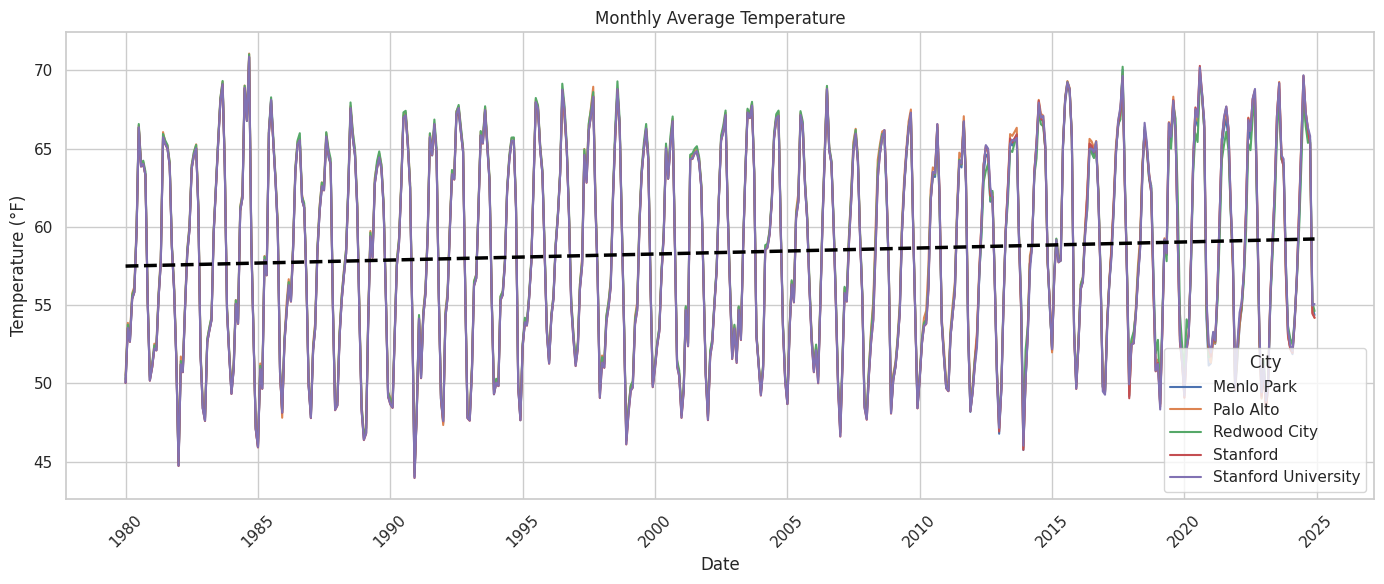

In [ ]:
# Plot monthly average temperature over time
plt.figure(figsize=(14, 6))
monthly_summary['year'] = monthly_summary['month'].dt.year
monthly_summary = monthly_summary[monthly_summary['year'] >= 1980]

for city in monthly_summary['city_name'].unique():
    city_data = monthly_summary[monthly_summary['city_name'] == city]
    plt.plot(city_data['month'].dt.to_timestamp(), city_data['temp'], label=city)

plt.title('Monthly Average Temperature')
plt.ylabel('Temperature (°F)')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.legend(title = 'City', loc = 'lower right')

# Continue from your existing figure
import numpy as np
from sklearn.linear_model import LinearRegression

# Create a numeric x-axis from the datetime for regression
trend_df = monthly_summary.copy()
trend_df['month_dt'] = trend_df['month'].dt.to_timestamp()
trend_df = trend_df.dropna(subset=['temp'])

# Convert month to numeric format for regression (ordinal)
X = trend_df['month_dt'].map(pd.Timestamp.toordinal).values.reshape(-1, 1)
y = trend_df['temp'].values

# Fit linear regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Overlay trend line
plt.plot(trend_df['month_dt'], y_pred, color='black', linewidth=2.5, linestyle='--', label='Trend Line')


plt.tight_layout()
plt.show()

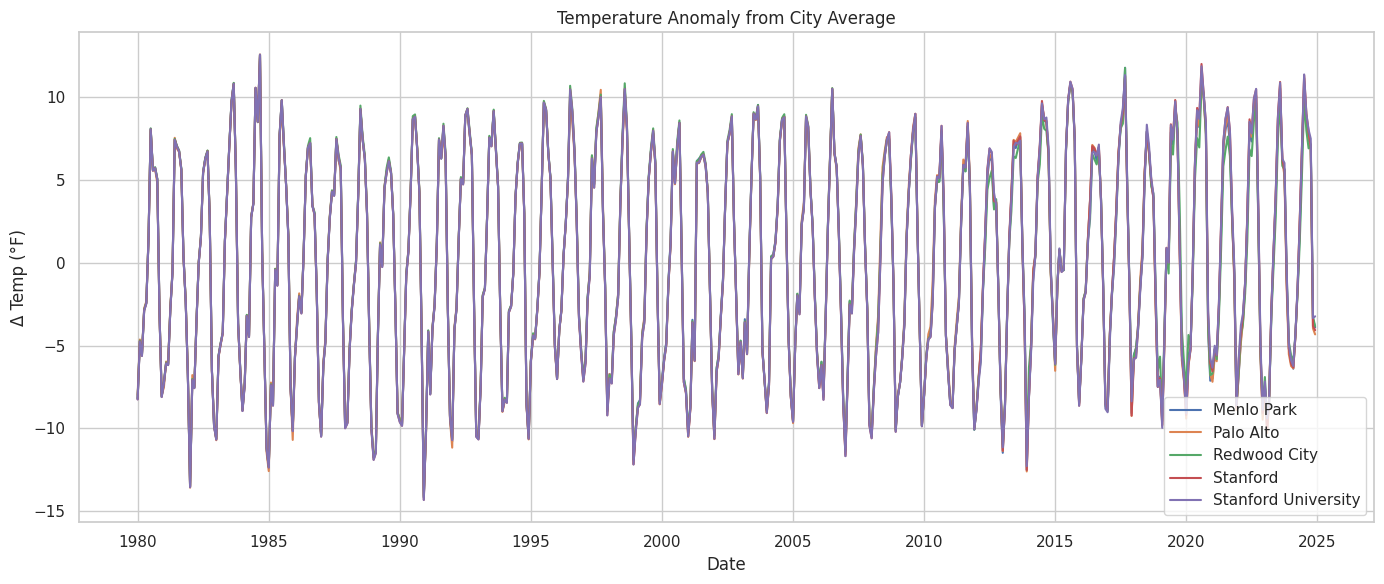

In [ ]:
# Compute baseline temp per city
city_means = monthly_summary.groupby('city_name')['temp'].mean().to_dict()

monthly_summary['temp_anomaly'] = monthly_summary.apply(
    lambda row: row['temp'] - city_means[row['city_name']], axis=1
)

# Plot anomalies
plt.figure(figsize=(14, 6))
for city in monthly_summary['city_name'].unique():
    city_data = monthly_summary[monthly_summary['city_name'] == city]
    plt.plot(city_data['month'].dt.to_timestamp(), city_data['temp_anomaly'], label=city)
plt.title('Temperature Anomaly from City Average')
plt.ylabel('Δ Temp (°F)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()


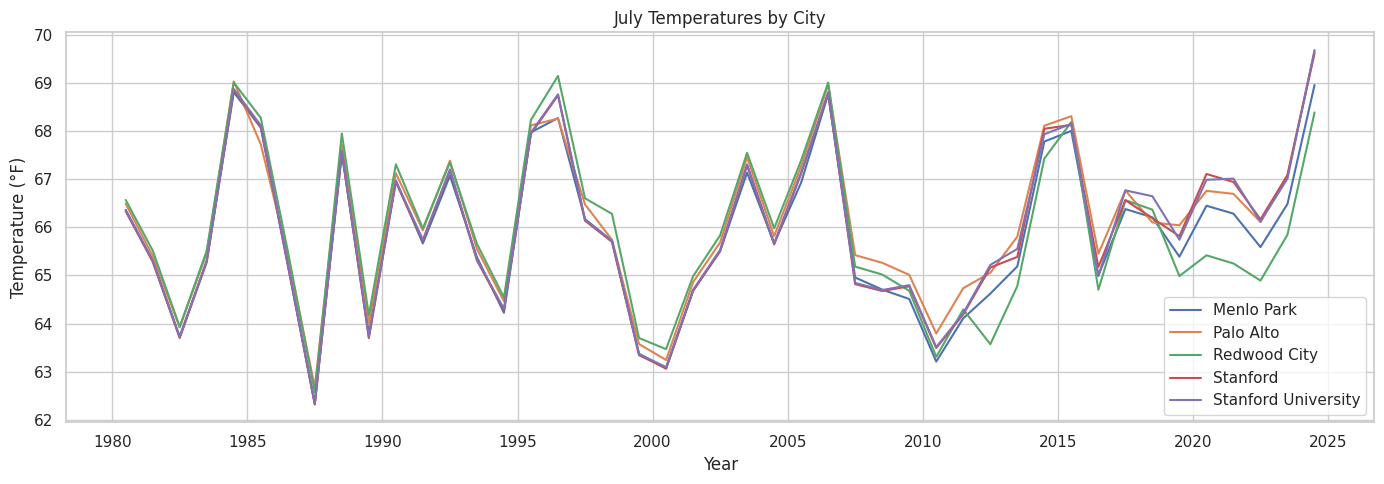

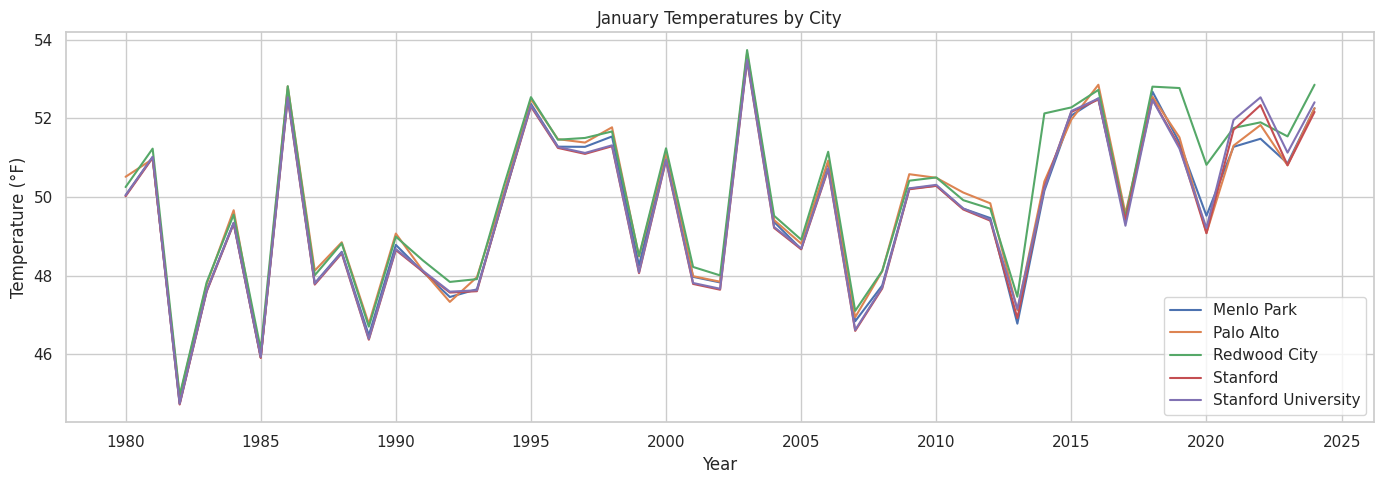

In [ ]:
summer = monthly_summary[monthly_summary['month'].dt.month == 7]
winter = monthly_summary[monthly_summary['month'].dt.month == 1]

def plot_summer_winter(df):
  month = "July" if df is summer else "January"
  plt.figure(figsize=(14, 5))
  for city in df['city_name'].unique():
      city_data = df[df['city_name'] == city]
      plt.plot(city_data['month'].dt.to_timestamp(), city_data['temp'], label=city)
  plt.title(f"{month} Temperatures by City")
  plt.xlabel('Year')
  plt.ylabel('Temperature (°F)')
  plt.legend()
  plt.tight_layout()
  plt.show()

plot_summer_winter(summer)
plot_summer_winter(winter)



### Check for stationarity over time

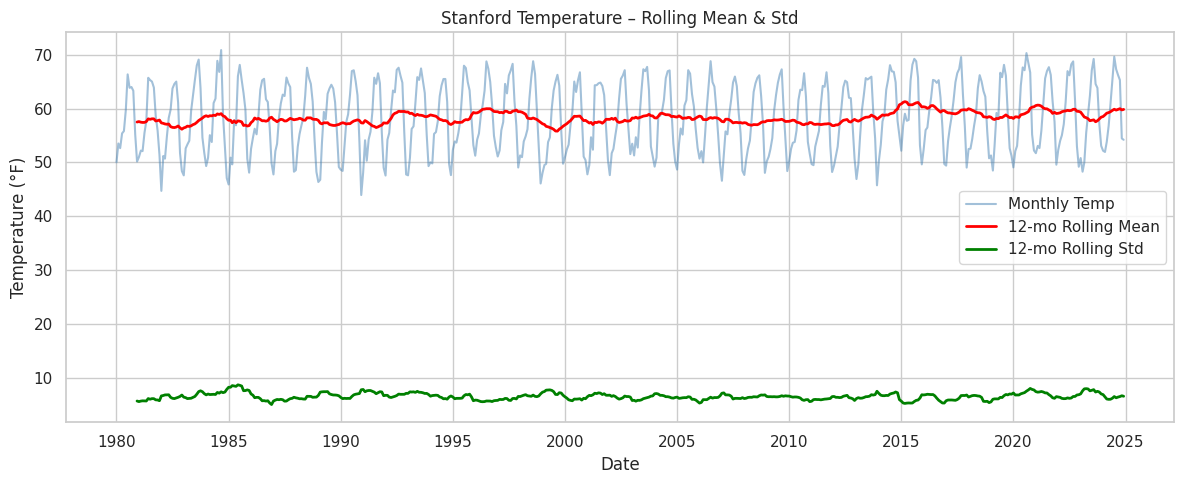

In [ ]:
import matplotlib.pyplot as plt

# --- focus on Stanford ---
stanford_temp = (
    monthly_summary[monthly_summary['city_name'] == 'Stanford']
    .set_index('month')['temp']
    .sort_index()
)

window = 12  # 12 months ≈ one year
roll_mean = stanford_temp.rolling(window=window).mean()
roll_std  = stanford_temp.rolling(window=window).std()

plt.figure(figsize=(12, 5))
plt.plot(stanford_temp.index.to_timestamp(), stanford_temp, label='Monthly Temp', color='steelblue', alpha=0.5)
plt.plot(roll_mean.index.to_timestamp(), roll_mean, label=f'{window}-mo Rolling Mean', color='red', linewidth=2)
plt.plot(roll_std.index.to_timestamp(), roll_std, label=f'{window}-mo Rolling Std', color='green', linewidth=2)
plt.title("Stanford Temperature – Rolling Mean & Std")
plt.xlabel("Date")
plt.ylabel("Temperature (°F)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
from statsmodels.tsa.stattools import adfuller

# drop NaNs just in case
temp_series = stanford_temp.dropna()

result = adfuller(temp_series)
print("ADF Statistic:", result[0])
print("p-value:",      result[1])
for key, val in result[4].items():
    print(f"Critical Value ({key}): {val:.3f}")

if result[1] < 0.05:
    print("\n✅ Reject H0 – series appears stationary.")
else:
    print("\n⚠️ Cannot reject H0 – series appears non-stationary (trend/seasonality present).")


ADF Statistic: -4.1068400303375325
p-value: 0.0009436156135243431
Critical Value (1%): -3.443
Critical Value (5%): -2.867
Critical Value (10%): -2.570

✅ Reject H0 – series appears stationary.


## Correlation Analysis of Temperature with Supplementary Variables

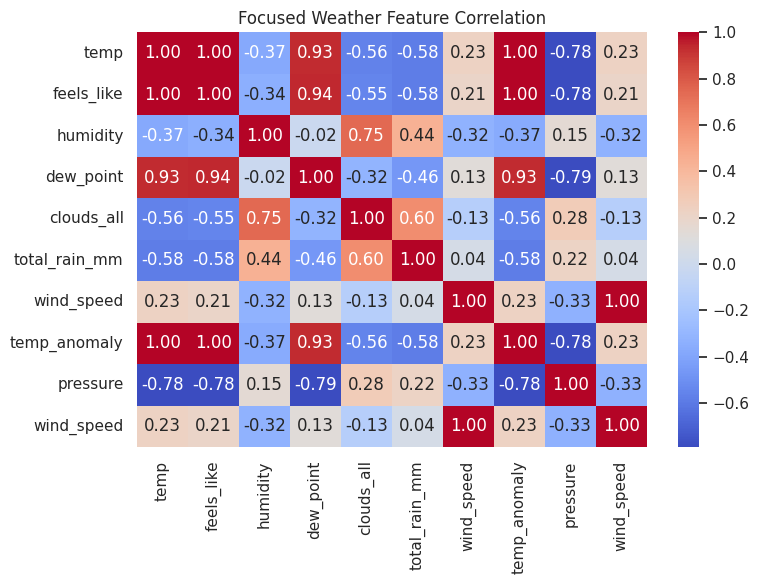

In [ ]:
# Keep only numeric columns for correlation
numeric_only = monthly_summary.select_dtypes(include='number')

vars_to_plot = [
    'temp', 'feels_like', 'humidity', 'dew_point',
    'clouds_all', 'total_rain_mm', 'wind_speed', 'temp_anomaly', 'pressure', 'wind_speed']

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_only[vars_to_plot].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Focused Weather Feature Correlation")
plt.tight_layout()
plt.show()


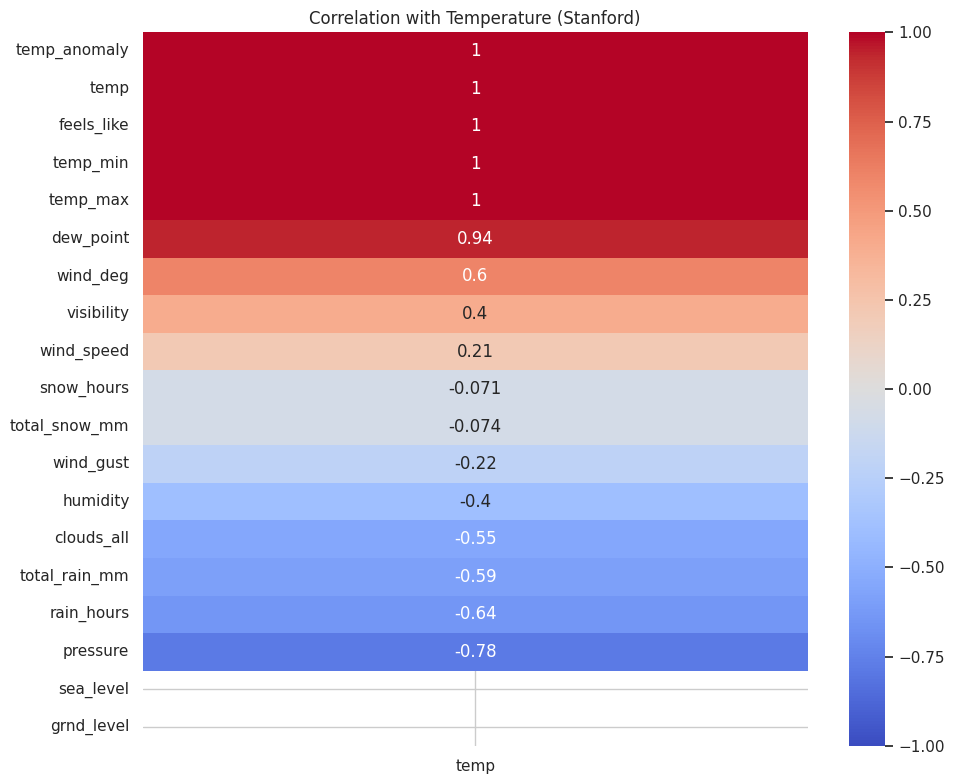

In [ ]:
# Drop columns with object/dict values
num_cols = monthly_summary.select_dtypes(include=['number'])

# Filter to Stanford only
stanford_df = monthly_summary[monthly_summary['city_name'] == 'Stanford']

# Compute correlation (only numerical cols)
corr = stanford_df[num_cols.columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr[['temp']].sort_values('temp', ascending=False), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation with Temperature (Stanford)")
plt.tight_layout()
plt.show()


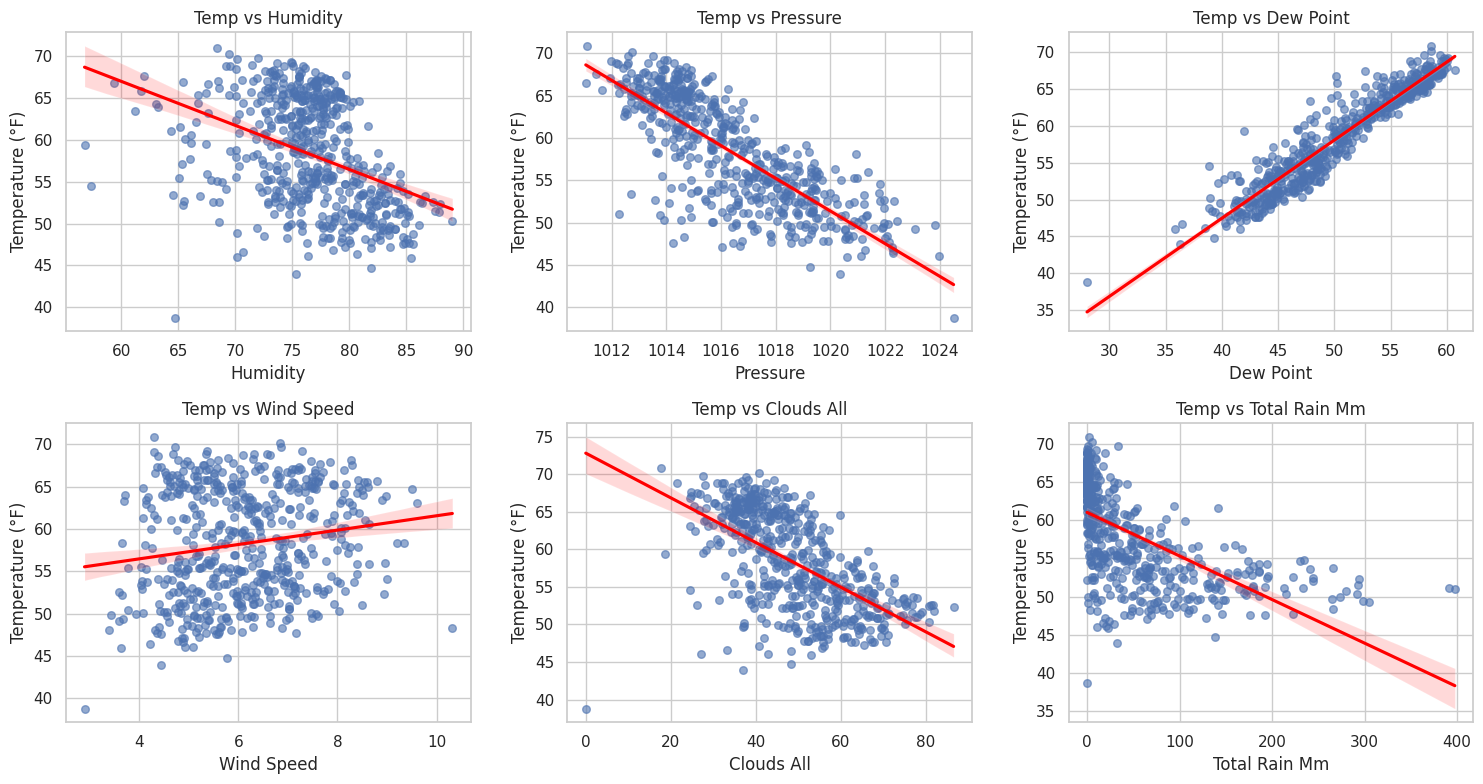

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of features to compare against temperature
features = ['humidity', 'pressure', 'dew_point', 'wind_speed', 'clouds_all', 'total_rain_mm']
n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

# Filter for Stanford
stanford_df = monthly_summary[monthly_summary['city_name'] == 'Stanford University'].copy()

# Plot grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]
    sns.regplot(
        data=stanford_df,
        x=feature,
        y='temp',
        ax=ax,
        scatter_kws={'s': 30, 'alpha': 0.6},
        line_kws={'color': 'red'}
    )
    ax.set_title(f"Temp vs {feature.replace('_', ' ').title()}")
    ax.set_xlabel(feature.replace('_', ' ').title())
    ax.set_ylabel("Temperature (°F)")

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

## Time Trends of supplementary variables by city

### Rainfall

In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

def plot_weather_trends(df, variable, label=None):
    """
    Plots annual and monthly trends for a given weather variable.
    Includes overall trendline for annual totals.

    Parameters:
        df (DataFrame): The monthly_summary dataframe.
        variable (str): Column name to analyze (e.g. 'total_rain_mm').
        label (str): Label for the y-axis (e.g. 'Rainfall (mm)'). If None, uses column name.
    """
    label = label or variable

    # Ensure year/month info exists
    df['year'] = df['month'].dt.year
    df = df[df['year'] >= 1980]
    df['month_num'] = df['month'].dt.month
    df['month_label'] = df['month_num'].map({
        1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
        7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
    })

    # === Annual Plot ===
    yearly = df.groupby(['city_name', 'year'])[variable].sum().reset_index()

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=yearly, x='year', y=variable, hue='city_name', marker='o')

    # One overall trendline
    X = yearly['year'].values.reshape(-1, 1)
    y = yearly[variable].values
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    plt.plot(yearly['year'], y_pred, color='black', linestyle='--', linewidth=2, label='Overall Trend')

    plt.title(f"Total Annual {label} by City (with Trendline)")
    plt.xlabel("Year")
    plt.ylabel(label)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # === Monthly Plot ===
    monthly = (
        df.groupby(['city_name', 'month_num', 'month_label'])[variable]
        .mean()
        .reset_index()
        .sort_values('month_num')
    )

    plt.figure(figsize=(10, 5))
    sns.lineplot(data=monthly, x='month_label', y=variable, hue='city_name', marker='o')
    plt.title(f"Average Monthly {label} by City")
    plt.xlabel("Month")
    plt.ylabel(f"Average {label}")
    plt.tight_layout()
    plt.show()


<ipython-input-96-1349447688>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_num'] = df['month'].dt.month
<ipython-input-96-1349447688>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_label'] = df['month_num'].map({


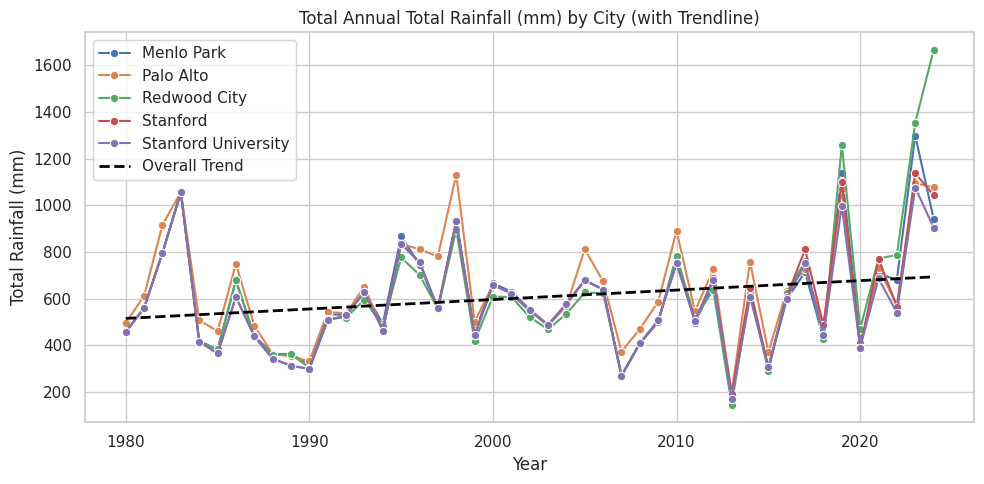

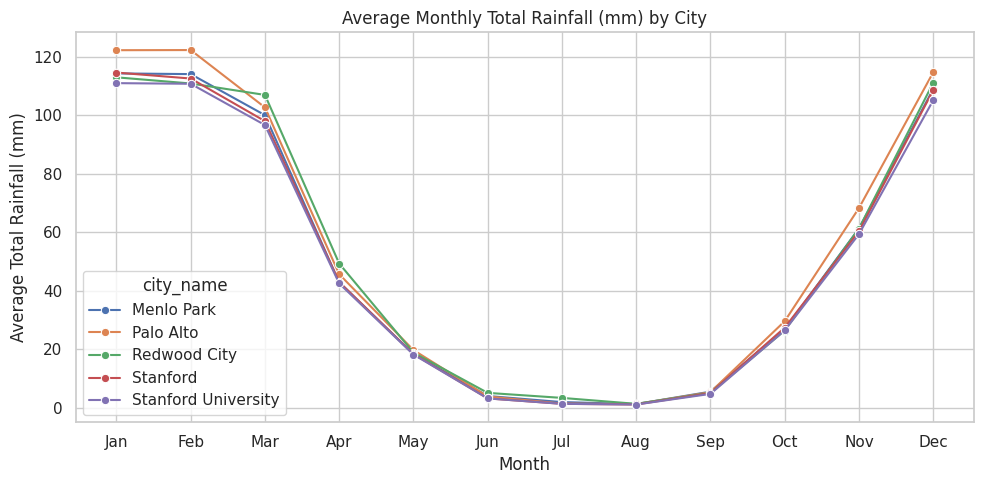

In [ ]:
plot_weather_trends(monthly_summary, variable='total_rain_mm', label='Total Rainfall (mm)')

### Cloud coverage

<ipython-input-96-1349447688>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_num'] = df['month'].dt.month
<ipython-input-96-1349447688>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_label'] = df['month_num'].map({


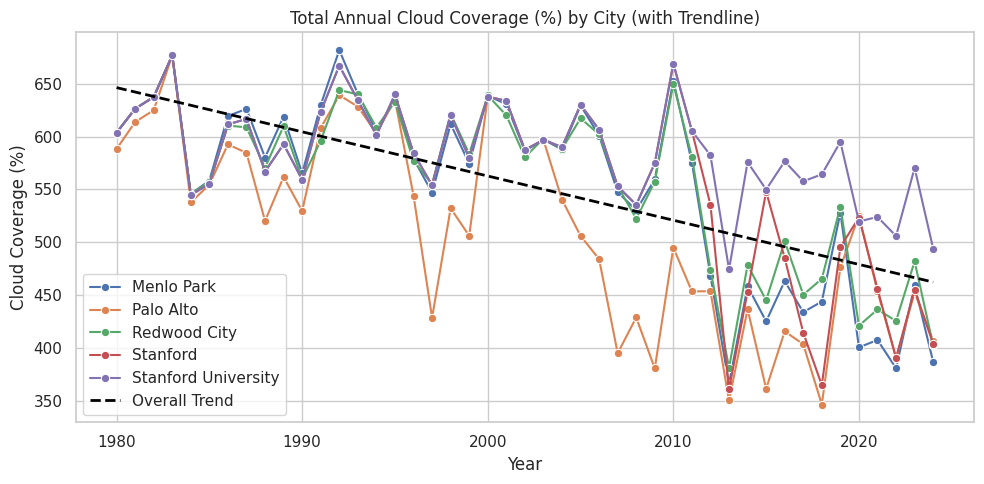

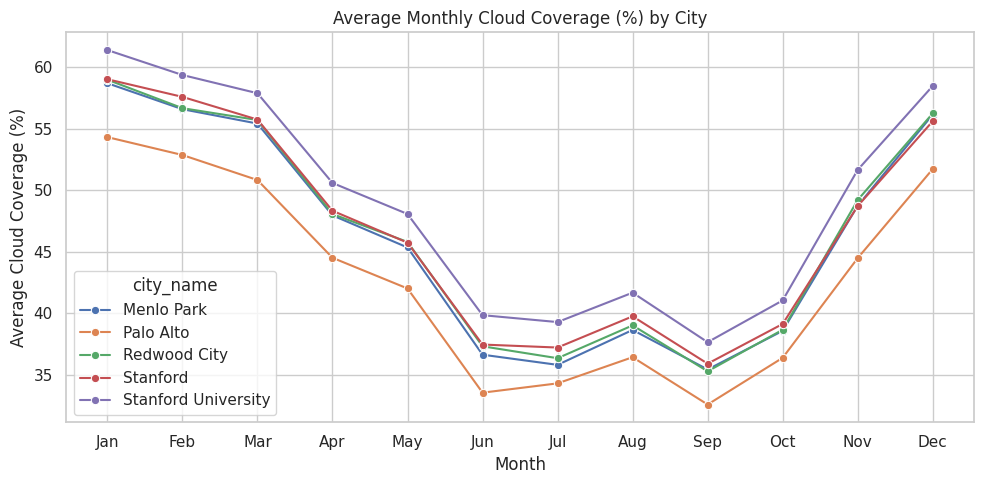

In [ ]:
# Sum cloud coverage per year, then average
plot_weather_trends(monthly_summary, variable='clouds_all', label='Cloud Coverage (%)')



### Wind speed

<ipython-input-96-1349447688>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_num'] = df['month'].dt.month
<ipython-input-96-1349447688>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_label'] = df['month_num'].map({


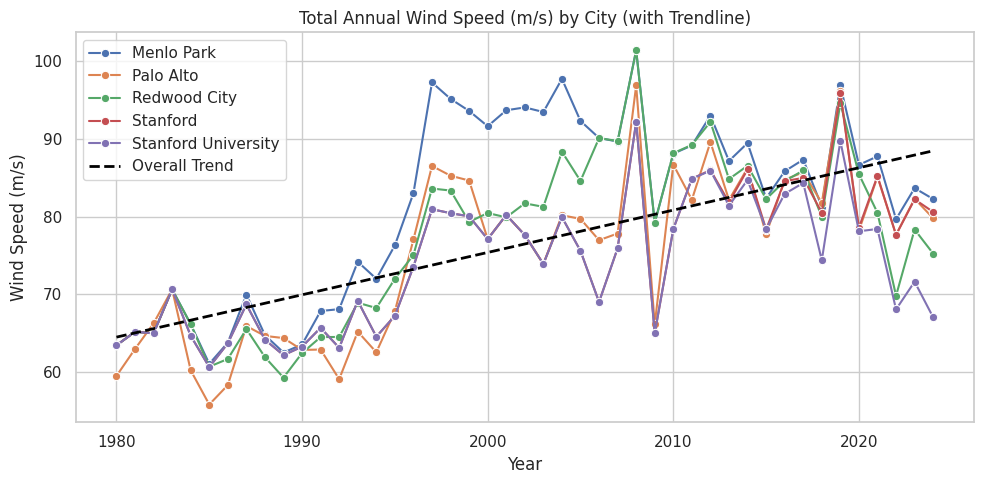

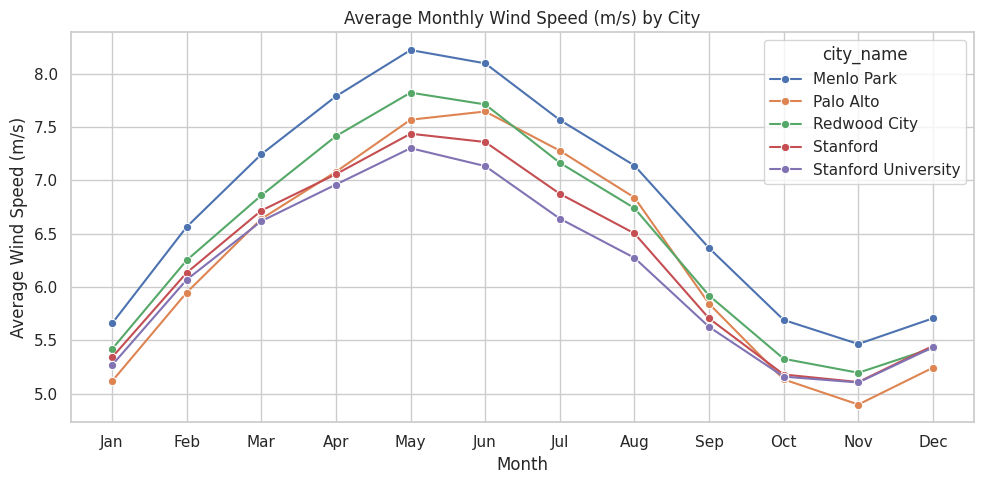

In [ ]:
plot_weather_trends(monthly_summary, variable='wind_speed', label='Wind Speed (m/s)')

### Pressure

<ipython-input-96-1349447688>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_num'] = df['month'].dt.month
<ipython-input-96-1349447688>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_label'] = df['month_num'].map({


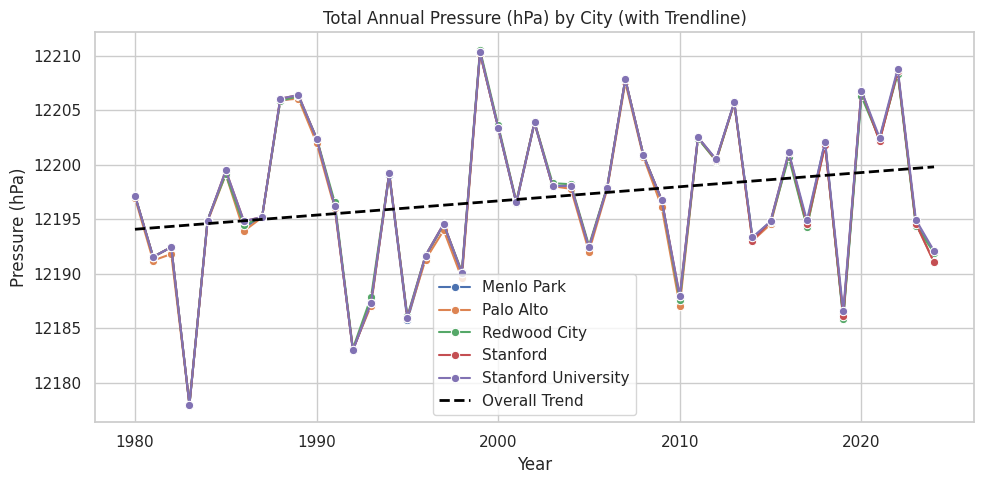

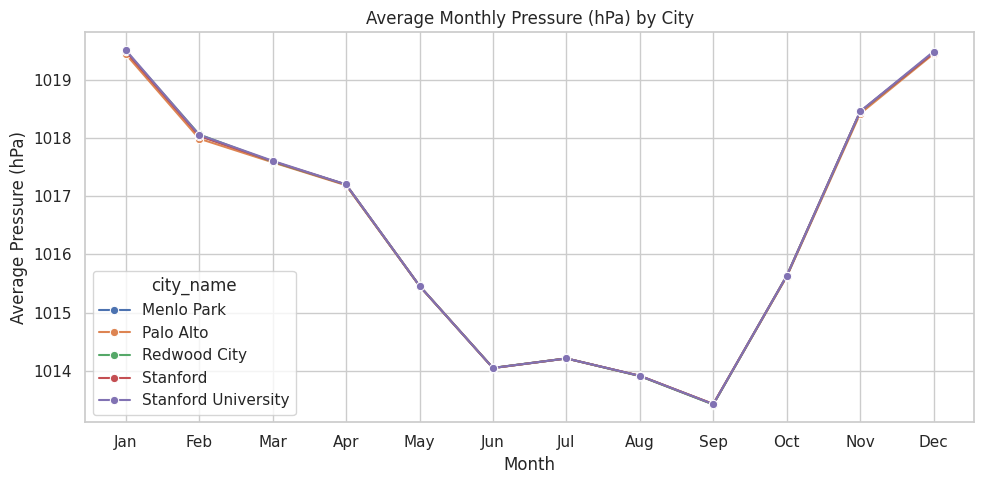

In [ ]:
plot_weather_trends(monthly_summary, variable='pressure', label='Pressure (hPa)')

### Humidity

<ipython-input-96-1349447688>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_num'] = df['month'].dt.month
<ipython-input-96-1349447688>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_label'] = df['month_num'].map({


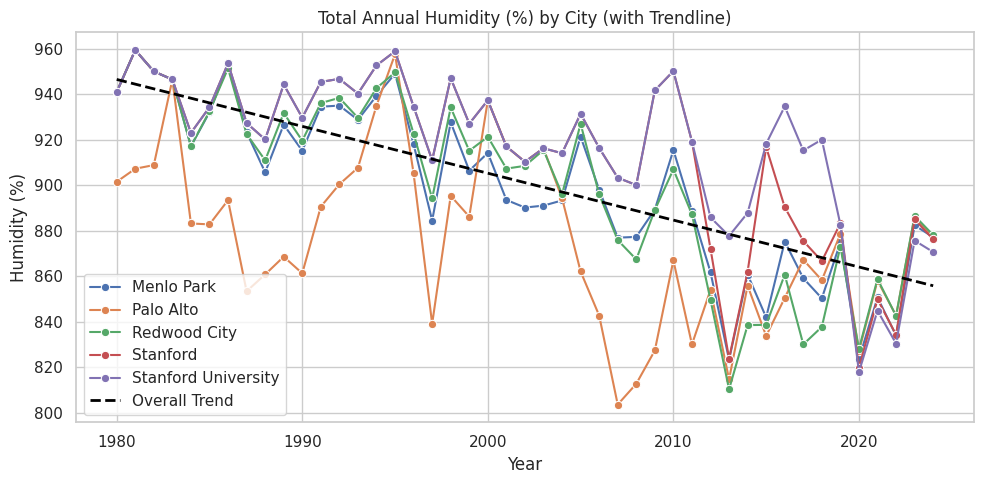

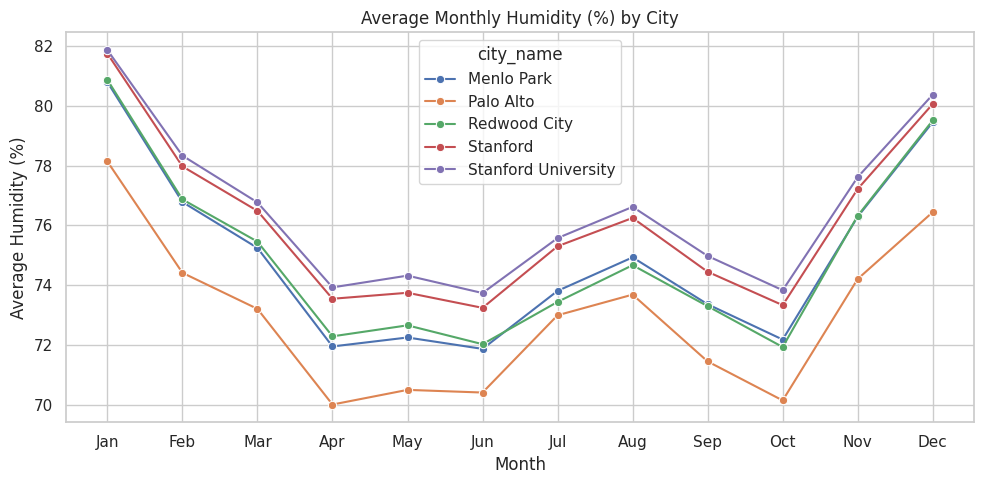

In [ ]:
plot_weather_trends(monthly_summary, variable='humidity', label='Humidity (%)')

### Dew point

<ipython-input-96-1349447688>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_num'] = df['month'].dt.month
<ipython-input-96-1349447688>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_label'] = df['month_num'].map({


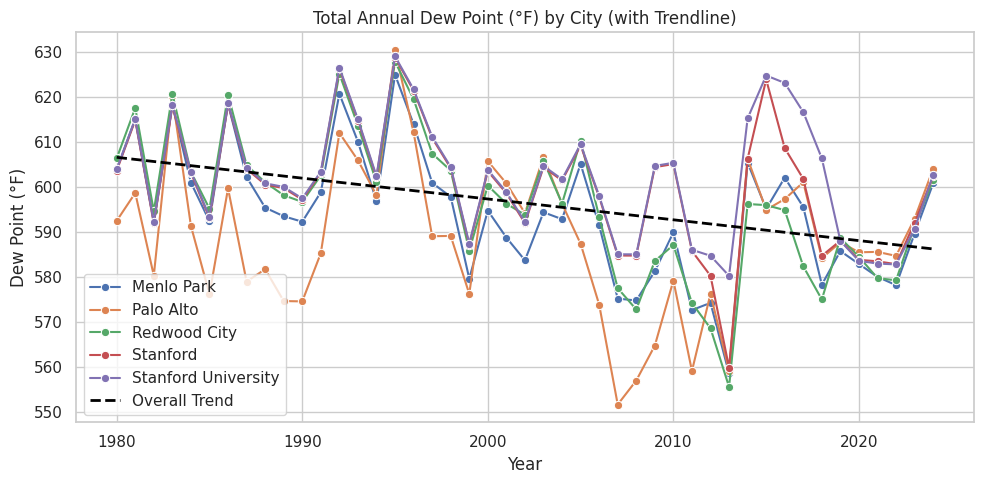

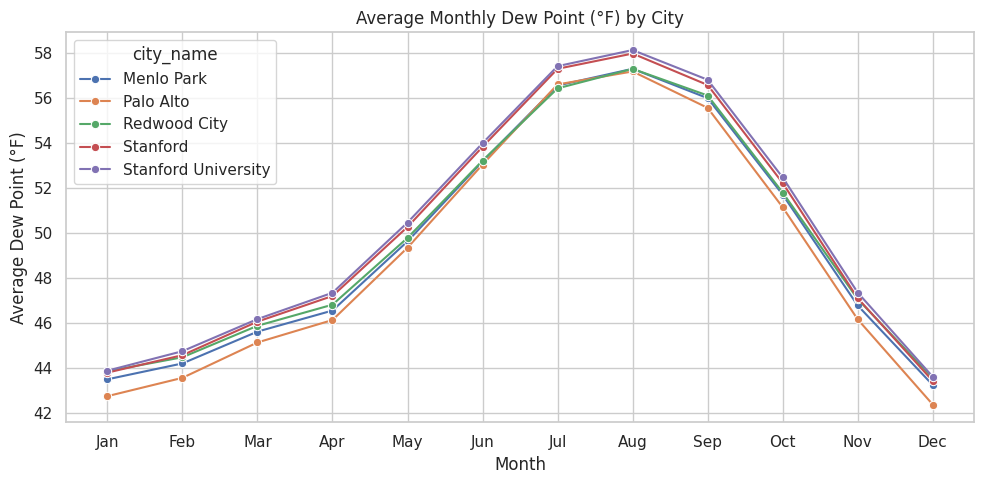

In [ ]:
plot_weather_trends(monthly_summary, variable='dew_point', label='Dew Point (°F)')

### Weather categories

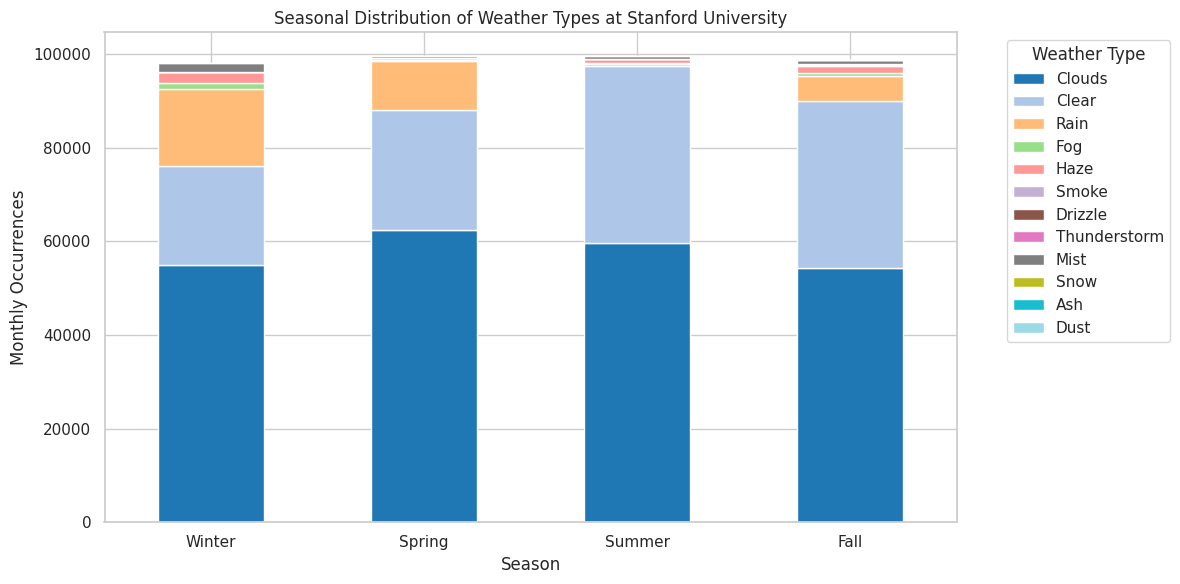

In [ ]:
from collections import Counter
from ast import literal_eval

# Extract season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

# Add season column
stanford_summary = monthly_summary[monthly_summary['city_name'] == 'Stanford University'].copy()
stanford_summary['season'] = stanford_summary['month'].dt.month.apply(get_season)

# Count weather_main occurrences by season
seasonal_counts = {season: Counter() for season in ['Winter', 'Spring', 'Summer', 'Fall']}

for _, row in stanford_summary.iterrows():
    season = row['season']
    counts = row['weather_main_counts']
    if isinstance(counts, str):
        counts = literal_eval(counts)
    if isinstance(counts, dict):
        seasonal_counts[season].update(counts)

# Convert to DataFrame for plotting
seasonal_df = pd.DataFrame(seasonal_counts).fillna(0).astype(int)

# Plot
seasonal_df.T.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
plt.title("Seasonal Distribution of Weather Types at Stanford University")
plt.xlabel("Season")
plt.ylabel("Monthly Occurrences")
plt.xticks(rotation=0)
plt.legend(title='Weather Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Lag Analysis

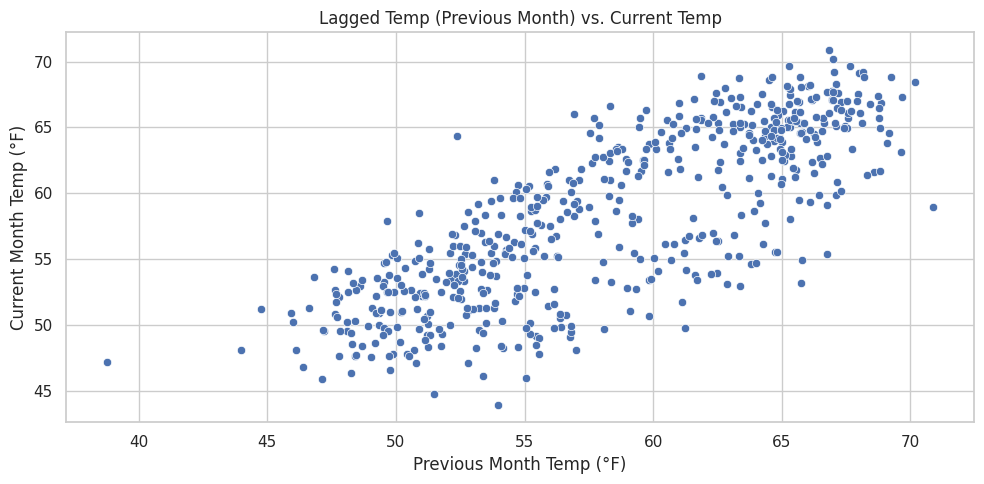

In [ ]:
stanford_df = stanford_df.sort_values('month')
stanford_df['temp_prev_month'] = stanford_df['temp'].shift(1)

plt.figure(figsize=(10, 5))
sns.scatterplot(data=stanford_df, x='temp_prev_month', y='temp')
plt.title("Lagged Temp (Previous Month) vs. Current Temp")
plt.xlabel("Previous Month Temp (°F)")
plt.ylabel("Current Month Temp (°F)")
plt.tight_layout()
plt.show()
